<a href="https://colab.research.google.com/github/Hiraz-cipher/D-B-Assignment/blob/main/Python_data_processing_(Part_3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries ready")

Libraries ready


In [ ]:
customers  = pd.read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/customers.csv")
orders     = pd.read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/orders.csv")
deliveries = pd.read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/deliveries.csv")
complaints = pd.read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/complaints.csv")
drivers    = pd.read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/drivers.csv")
vehicles   = pd.read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/vehicles.csv")
hubs       = pd.read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/hubs.csv")
incidents  = pd.read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/incidents.csv")
app_events = pd.read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/app_events.csv" )

for name, df in [('customers',customers),('orders',orders),
                 ('deliveries',deliveries),('complaints',complaints),
                 ('drivers',drivers),('vehicles',vehicles),
                 ('hubs',hubs),('incidents',incidents),('app_events',app_events)]:
    print(f"{name}: {len(df)} rows, {len(df.columns)} columns")

customers: 650 rows, 9 columns
orders: 1250 rows, 11 columns
deliveries: 950 rows, 13 columns
complaints: 320 rows, 10 columns
drivers: 170 rows, 8 columns
vehicles: 120 rows, 8 columns
hubs: 8 rows, 5 columns
incidents: 280 rows, 7 columns
app_events: 640 rows, 10 columns


In [ ]:
def clean_zone(value):
    if pd.isna(value):
        return value
    value = str(value).strip().upper()
    if value == 'CTR':
        value = 'CENTRAL'
    return value

customers['home_zone']       = customers['home_zone'].apply(clean_zone)
orders['pickup_zone']        = orders['pickup_zone'].apply(clean_zone)
orders['dropoff_zone']       = orders['dropoff_zone'].apply(clean_zone)
drivers['base_zone']         = drivers['base_zone'].apply(clean_zone)
vehicles['assigned_zone']    = vehicles['assigned_zone'].apply(clean_zone)
hubs['zone']                 = hubs['zone'].apply(clean_zone)
app_events['zone_context']   = app_events['zone_context'].apply(clean_zone)

print("Zones cleaned across all files.")
print("Unique zones in orders pickup_zone:", sorted(orders['pickup_zone'].dropna().unique()))

Zones cleaned across all files.
Unique zones in orders pickup_zone: ['AIRPORT', 'CENTRAL', 'EAST', 'NORTH', 'RIVERSIDE', 'SOUTH', 'WEST']


In [ ]:
print("=== MISSING VALUES IN ALL 9 FILES ===\n")

all_files = {
    'customers': customers, 'orders': orders, 'deliveries': deliveries,
    'complaints': complaints, 'drivers': drivers, 'vehicles': vehicles,
    'hubs': hubs, 'incidents': incidents, 'app_events': app_events
}

for name, df in all_files.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"{name}.csv:")
        for col, cnt in missing.items():
            pct = round(100 * cnt / len(df), 1)
            print(f"  {col}: {cnt} missing ({pct}%)")
        print()
    else:
        print(f"{name}.csv: No missing values")

# Handle missing values
customers['loyalty_score'].fillna(customers['loyalty_score'].median(), inplace=True)
drivers['training_score'].fillna(drivers['training_score'].median(), inplace=True)
vehicles['battery_health_pct'].fillna(vehicles['battery_health_pct'].median(), inplace=True)
complaints['compensation_amount'].fillna(0, inplace=True)
incidents['resolved_hours'].fillna(incidents['resolved_hours'].median(), inplace=True)
orders['booking_channel'].fillna('Unknown', inplace=True)

print("\nMissing values handled.")

=== MISSING VALUES IN ALL 9 FILES ===

customers.csv:
  preferred_channel: 13 missing (2.0%)

orders.csv: No missing values
deliveries.csv:
  delivery_completed_at: 19 missing (2.0%)
  customer_rating_post_delivery: 14 missing (1.5%)

complaints.csv: No missing values
drivers.csv: No missing values
vehicles.csv: No missing values
hubs.csv: No missing values
incidents.csv: No missing values
app_events.csv:
  order_id: 144 missing (22.5%)


Missing values handled.


/tmp/ipykernel_5859/3608116375.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers['loyalty_score'].fillna(customers['loyalty_score'].median(), inplace=True)
/tmp/ipykernel_5859/3608116375.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[c

In [ ]:
# Merge deliveries with orders and hubs
del_full = deliveries.merge(
    orders[['order_id', 'service_type', 'pickup_zone', 'order_value', 'priority_level']],
    on='order_id', how='left'
).merge(
    hubs[['hub_id', 'hub_name', 'zone', 'hub_type', 'capacity_score']],
    on='hub_id', how='left'
)

# Summary by service type
print("=== DELIVERY OUTCOME BY SERVICE TYPE ===")
service_summary = del_full.groupby('service_type')['delivery_status'].value_counts(
    normalize=True).mul(100).round(1).unstack(fill_value=0)
print(service_summary)

=== DELIVERY OUTCOME BY SERVICE TYPE ===
delivery_status  Delayed  Failed  OnTime
service_type                            
Business            22.2    19.8    57.9
Medical             20.4    14.8    64.8
Parcel              21.3    10.9    67.8
Passenger           20.2    14.5    65.3
Retail              22.3    12.5    65.2


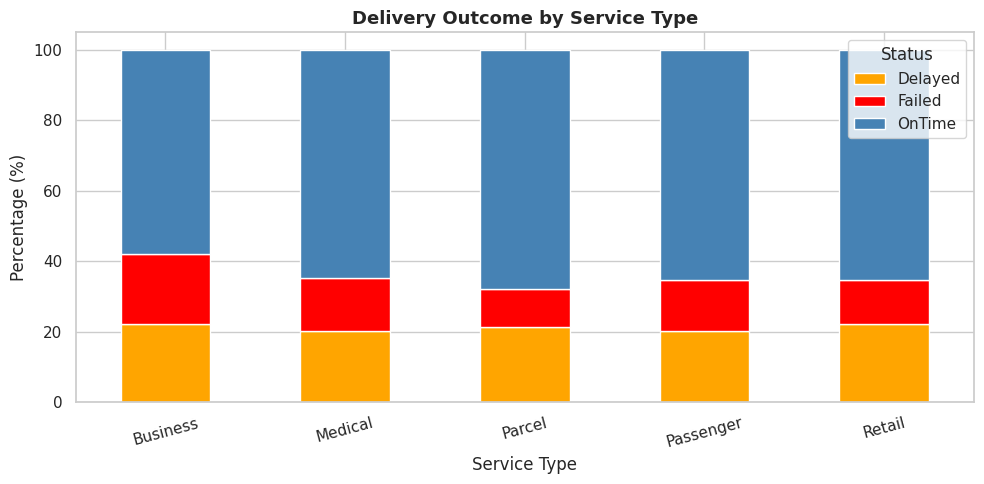


Source: deliveries.csv merged with orders.csv


In [ ]:
service_counts = del_full.groupby(['service_type', 'delivery_status']).size().unstack(fill_value=0)
service_pct = service_counts.div(service_counts.sum(axis=1), axis=0) * 100

service_pct.plot(kind='bar', stacked=True,
                  color={'Failed': 'red', 'Delayed': 'orange', 'OnTime': 'steelblue'},
                  figsize=(10, 5))

plt.title('Delivery Outcome by Service Type', fontsize=13, fontweight='bold')
plt.xlabel('Service Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=15)
plt.legend(title='Status')
plt.tight_layout()
plt.savefig('chart1_service_outcomes.png')
plt.show()

print("\nSource: deliveries.csv merged with orders.csv")

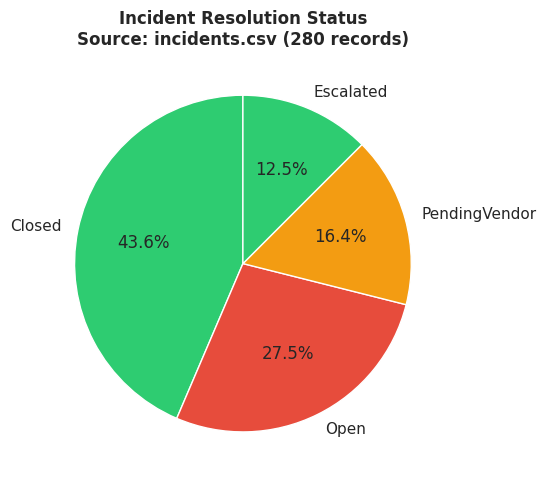

resolution_status
Closed           122
Open              77
PendingVendor     46
Escalated         35
Name: count, dtype: int64

Incidents not yet closed (Open + Escalated): 158


In [ ]:
# incidents.csv — resolution status breakdown
res_counts = incidents['resolution_status'].value_counts()

colours = ['#2ecc71', '#e74c3c', '#f39c12']
plt.figure(figsize=(7, 5))
plt.pie(res_counts.values, labels=res_counts.index,
        autopct='%1.1f%%', colors=colours, startangle=90)
plt.title('Incident Resolution Status\nSource: incidents.csv (280 records)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_incident_resolution.png')
plt.show()

print(res_counts)
print("\nIncidents not yet closed (Open + Escalated):",
      incidents[incidents['resolution_status'] != 'Closed'].shape[0])

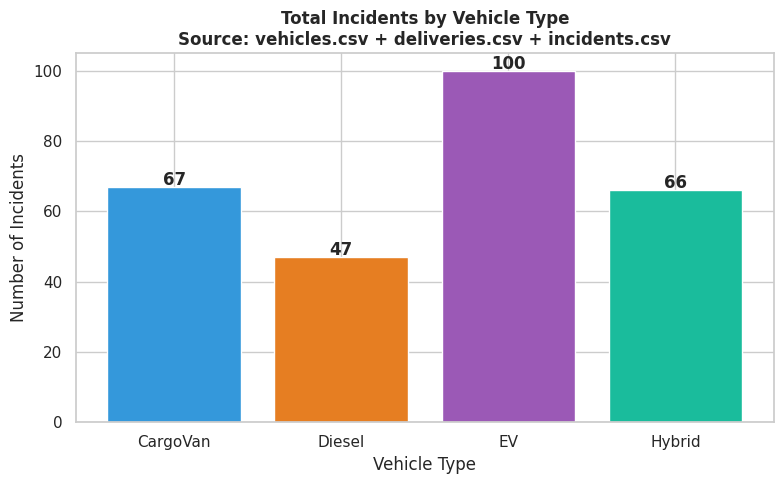

In [ ]:
# Join all three files together
veh_del_inc = deliveries.merge(
    vehicles[['vehicle_id', 'vehicle_type', 'maintenance_status', 'battery_health_pct']],
    on='vehicle_id', how='left'
).merge(
    incidents[['delivery_id', 'incident_type']],
    on='delivery_id', how='left'
)

# Count incidents per vehicle type
veh_inc = veh_del_inc.groupby('vehicle_type')['incident_type'].count().reset_index()
veh_inc.columns = ['vehicle_type', 'incident_count']

plt.figure(figsize=(8, 5))
bars = plt.bar(veh_inc['vehicle_type'], veh_inc['incident_count'],
               color=['#3498db', '#e67e22', '#9b59b6', '#1abc9c'])
plt.title('Total Incidents by Vehicle Type\nSource: vehicles.csv + deliveries.csv + incidents.csv',
          fontsize=12, fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Number of Incidents')
for bar, val in zip(bars, veh_inc['incident_count']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_vehicle_incidents.png')
plt.show()

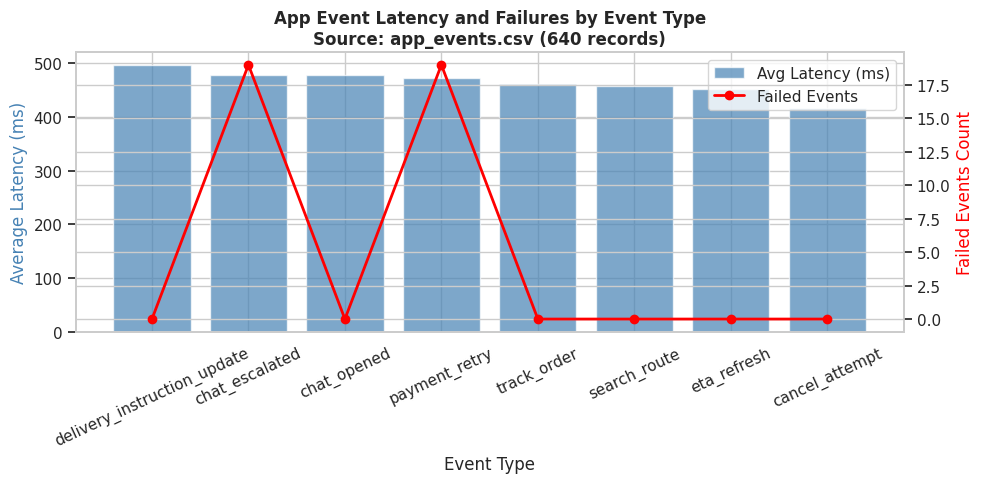

                 event_type  avg_latency  failed_count  total
delivery_instruction_update        496.0             0     75
             chat_escalated        478.0            19     38
                chat_opened        478.0             0     88
              payment_retry        473.0            19     69
                track_order        461.0             0    138
               search_route        457.0             0     99
                eta_refresh        452.0             0    105
             cancel_attempt        417.0             0     28

Source: app_events.csv


In [ ]:
# app_events.csv — which event types are slowest?
latency = app_events.groupby('event_type').agg(
    avg_latency = ('api_latency_ms', 'mean'),
    failed_count = ('success_flag', lambda x: (x == 0).sum()),
    total = ('event_id', 'count')
).reset_index()
latency['avg_latency'] = latency['avg_latency'].round(0)
latency = latency.sort_values('avg_latency', ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

bars = ax1.bar(latency['event_type'], latency['avg_latency'],
               color='steelblue', alpha=0.7, label='Avg Latency (ms)')
ax2.plot(latency['event_type'], latency['failed_count'],
         color='red', marker='o', linewidth=2, label='Failed Events')

ax1.set_xlabel('Event Type')
ax1.set_ylabel('Average Latency (ms)', color='steelblue')
ax2.set_ylabel('Failed Events Count', color='red')
ax1.set_title('App Event Latency and Failures by Event Type\nSource: app_events.csv (640 records)',
          fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=25)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('chart4_app_latency.png')
plt.show()

print(latency.to_string(index=False))
print("\nSource: app_events.csv")

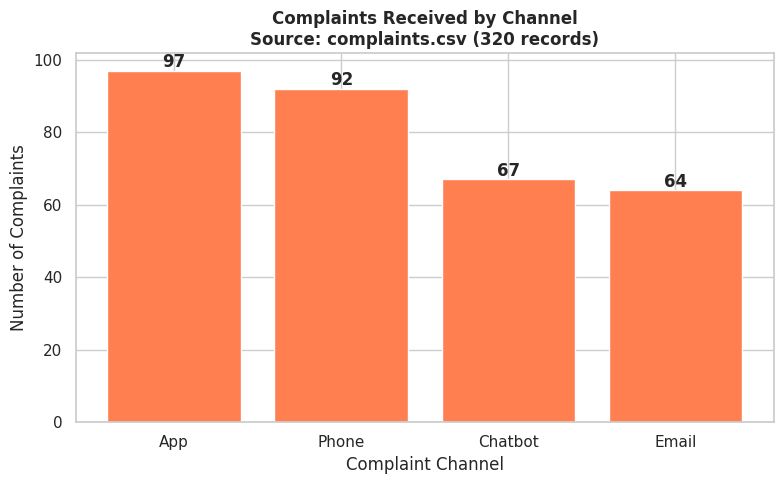


Average resolution days by channel:
channel
App        8.3
Chatbot    7.5
Email      7.6
Phone      8.0
Name: resolution_days, dtype: float64


In [ ]:
# complaints.csv — which channel do customers use to complain?
channel_counts = complaints['channel'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(channel_counts.index, channel_counts.values, color='coral')
plt.title('Complaints Received by Channel\nSource: complaints.csv (320 records)',
          fontsize=12, fontweight='bold')
plt.xlabel('Complaint Channel')
plt.ylabel('Number of Complaints')
for i, val in enumerate(channel_counts.values):
    plt.text(i, val + 1, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_complaint_channels.png')
plt.show()

# Also show average resolution days per channel
print("\nAverage resolution days by channel:")
print(complaints.groupby('channel')['resolution_days'].mean().round(1))

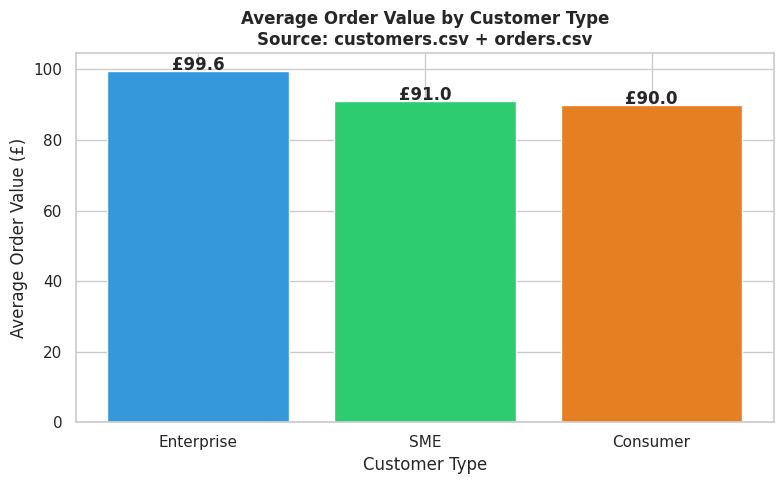

customer_type
Enterprise    99.64
SME           91.02
Consumer      89.95
Name: order_value, dtype: float64


In [ ]:
# Join customers to orders
cust_orders = orders.merge(
    customers[['customer_id', 'customer_type', 'loyalty_score', 'home_zone']],
    on='customer_id', how='left'
)

# Average order value per customer type
avg_val = cust_orders.groupby('customer_type')['order_value'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(avg_val.index, avg_val.values,
               color=['#3498db','#2ecc71','#e67e22','#9b59b6','#e74c3c'])
plt.title('Average Order Value by Customer Type\nSource: customers.csv + orders.csv',
          fontsize=12, fontweight='bold')
plt.xlabel('Customer Type')
plt.ylabel('Average Order Value (£)')
for bar, val in zip(bars, avg_val.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'£{val:.1f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart6_order_value.png')
plt.show()

print(avg_val.round(2))

In [ ]:
print("=" * 60)
print("NORTHSTAR — KEY FINDINGS ACROSS ALL 9 FILES")
print("=" * 60)

# From deliveries.csv
fail_rate = round(100 * (deliveries['delivery_status'] == 'Failed').mean(), 1)
delay_rate = round(100 * (deliveries['delivery_status'] == 'Delayed').mean(), 1)
print(f"\ndeliveries.csv:")
print(f"  Failed deliveries:  {fail_rate}%")
print(f"  Delayed deliveries: {delay_rate}%")

# From incidents.csv
unresolved = (incidents['resolution_status'] != 'Closed').sum()
print(f"\nincidents.csv:")
print(f"  Unresolved incidents: {unresolved} of {len(incidents)}")
battery_issues = (incidents['incident_type'] == 'BatteryAlert').sum()
print(f"  BatteryAlert incidents: {battery_issues}")

# From vehicles.csv
in_repair = (vehicles['maintenance_status'] == 'InRepair').sum()
print(f"\nvehicles.csv:")
print(f"  Vehicles InRepair: {in_repair} of {len(vehicles)} ({round(100*in_repair/len(vehicles),1)}%)")

# From app_events.csv
app_fail = (app_events['success_flag'] == 0).sum()
print(f"\napp_events.csv:")
print(f"  Failed app events: {app_fail} of {len(app_events)} ({round(100*app_fail/len(app_events),1)}%)")

# From complaints.csv
high_open = complaints[(complaints['severity']=='High') & (complaints['status']=='Open')].shape[0]
print(f"\ncomplaints.csv:")
print(f"  Open High severity complaints: {high_open}")

# From drivers.csv
contract = (drivers['employment_type'] == 'Contract').sum()
print(f"\ndrivers.csv:")
print(f"  Contract drivers: {contract} of {len(drivers)}")

print("\n→ These findings across all 9 files tell the full NorthStar story.")

NORTHSTAR — KEY FINDINGS ACROSS ALL 9 FILES

deliveries.csv:
  Failed deliveries:  13.9%
  Delayed deliveries: 21.3%

incidents.csv:
  Unresolved incidents: 158 of 280
  BatteryAlert incidents: 36

vehicles.csv:
  Vehicles InRepair: 36 of 120 (30.0%)

app_events.csv:
  Failed app events: 38 of 640 (5.9%)

complaints.csv:
  Open High severity complaints: 14

drivers.csv:
  Contract drivers: 20 of 170

→ These findings across all 9 files tell the full NorthStar story.
